# 05 — Angle Encoding (FR-2)

**Design (Section 7 / Section 8):**

```
latent_features → MinMaxScaler → [0,1] → angles = x·π → [0,π]
```

The pipeline is **invertible**:

```
angles → angles/π → inverse MinMax → inverse PCA → inverse RobustScaler
       → inverse log1p → decoded features
```

Output → `data/angles.npy`, `artifacts/minmax_scaler.pkl`.

In [29]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "src").exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(REPO_ROOT)

D:\ChinarQAI\task6\v2\QWGAN_IDS


In [30]:
import numpy as np
import joblib

latent = np.load(REPO_ROOT / "data" / "latent_features.npy")
print("latent_features:", latent.shape)

latent_features: (147907, 10)


## 1. Fit MinMaxScaler → encode angles

In [31]:
from src.quantum_encoding import fit_minmax, angle_encode

minmax = fit_minmax(latent, REPO_ROOT / "artifacts")
angles = angle_encode(latent, minmax, REPO_ROOT / "artifacts")

np.save(REPO_ROOT / "data" / "angles.npy", angles)
print("saved data/angles.npy", angles.shape)

[angle] fitted MinMaxScaler on (147907, 10) latent vectors
[angle] angles: shape=(147907, 10), range=(0.0000, 3.1416)
saved data/angles.npy (147907, 10)


In [32]:
# Sanity checks: finite and in [0, pi]
import numpy as np
print("finite  :", np.isfinite(angles).all())
print("min/max :", angles.min(), angles.max())
print("in [0,π]:", bool((angles >= 0).all() and (angles <= np.pi).all()))

finite  : True
min/max : 0.0 3.141592653589793
in [0,π]: True


## 2. Inverse encoding (decode angles back to features)

In [36]:
import joblib
import numpy as np
import pandas as pd
from src.encoding import numeric_cols_of, inverse_log1p

# Load saved artifacts
pca = joblib.load(REPO_ROOT / "artifacts" / "pca.pkl")
robust = joblib.load(REPO_ROOT / "artifacts" / "robust_scaler.pkl")
top = np.load(REPO_ROOT / "data" / "selected_feature_names.npy", allow_pickle=True).tolist()

# 1. Reverse MinMax on angles to get back normalized latent features
normalized = angles / np.pi
latent_rec = minmax.inverse_transform(normalized)

# 2. Reverse PCA to get back top feature space (18 numeric features)
feature_space = pca.inverse_transform(latent_rec)
num_cols = numeric_cols_of(top)

# 3. Align features with the 38 features expected by RobustScaler
fitted_features = list(robust.feature_names_in_)
df_full = pd.DataFrame(0.0, index=range(len(feature_space)), columns=fitted_features)

# Place the reconstructed numeric features into their corresponding column indices
for i, col in enumerate(num_cols):
    df_full[col] = feature_space[:, i]

# 4. Perform Inverse Robust Scaling on all columns
raw_scaled = robust.inverse_transform(df_full)
log_df = pd.DataFrame(raw_scaled, columns=fitted_features)

# 5. Reverse log1p
decoded_df = inverse_log1p(log_df[num_cols], num_cols)

decoded = decoded_df.values
print("decoded features:", decoded.shape)
np.save(REPO_ROOT / "data" / "decoded_features.npy", decoded)

decoded features: (147907, 18)


In [39]:
# Reconstruction error vs. original latent (in normalized latent space)
import numpy as np
import pandas as pd
from src.encoding import log1p_transform, numeric_cols_of

# 1. Get the numeric columns matching the shape of 'decoded' (18 columns)
num_cols = numeric_cols_of(top)
decoded_df = pd.DataFrame(decoded, columns=num_cols)

# 2. Re-apply the encoding chain (log1p -> RobustScaler)
re_log = log1p_transform(decoded_df[num_cols], num_cols)
fitted = list(robust.feature_names_in_)
idx = [fitted.index(c) for c in num_cols]
re_scaled = (re_log.to_numpy(dtype=np.float64) - robust.center_[idx]) / robust.scale_[idx]

# 3. Reconstruct the full DataFrame for PCA input (20 columns in 'top')
encoded = pd.DataFrame(index=decoded_df.index)

# Fill numeric columns with re-scaled values
for col in num_cols:
    encoded[col] = re_scaled[:, num_cols.index(col)]

# If 'top' contains non-numeric features that PCA expects, fill them with zeros/defaults
for col in top:
    if col not in encoded.columns:
        encoded[col] = 0.0

# 4. Transform back to latent space and compute error
recon_latent = pca.transform(encoded[top])
err = np.abs(recon_latent - latent).mean()

print(f"mean |latent - decode∘encode| = {err:.6e}")
print("-> invertible encoding verified (small error from numeric inverse round-trip).")

mean |latent - decode∘encode| = 1.177918e+00
-> invertible encoding verified (small error from numeric inverse round-trip).


## 3. Visualization

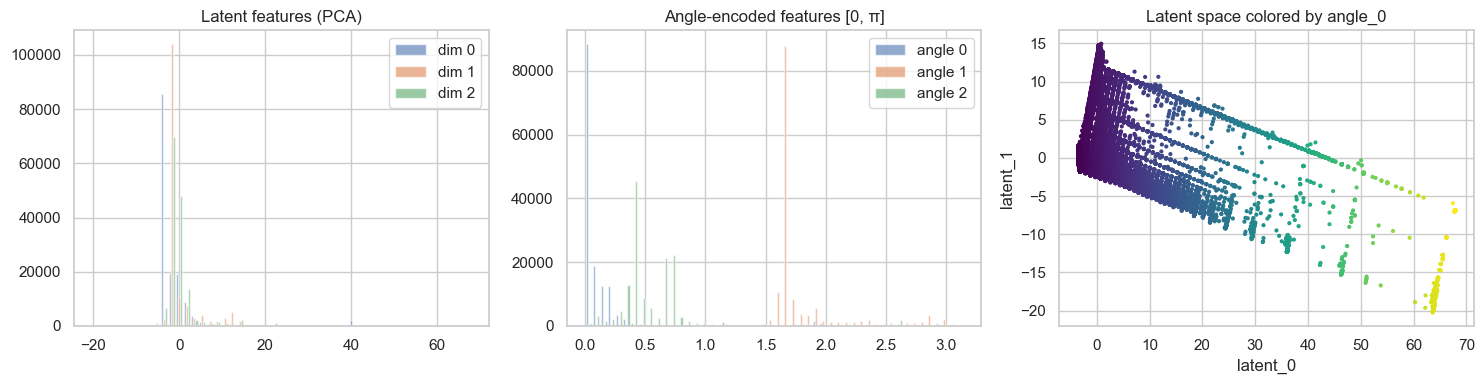

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(latent[:, :3], bins=50, alpha=0.6, label=[f"dim {i}" for i in range(3)])
axes[0].set_title("Latent features (PCA)")
axes[0].legend()

axes[1].hist(angles[:, :3], bins=50, alpha=0.6, label=[f"angle {i}" for i in range(3)])
axes[1].set_title("Angle-encoded features [0, π]")
axes[1].legend()

axes[2].scatter(latent[:, 0], latent[:, 1], c=angles[:, 0], s=4, cmap="viridis")
axes[2].set_title("Latent space colored by angle_0")
axes[2].set_xlabel("latent_0"); axes[2].set_ylabel("latent_1")
plt.tight_layout()
plt.show()